In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
df = pd.read_csv("data (1).csv")

In [28]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [29]:
X = df.drop("target", axis=1)
y = df["target"]

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
y_pred = lr.predict(X_test)
residuals = y_test - y_pred 

# 1.Linear Relationship

Text(0.5, 1.0, 'Feature 3 vs Target')

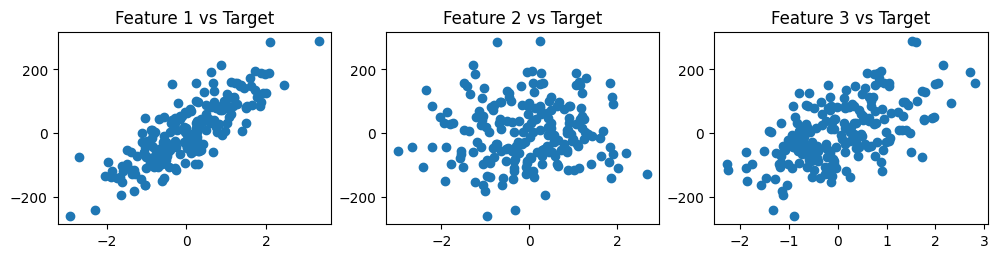

In [34]:
fig , (ax1,ax2,ax3) = plt.subplots(ncols=3, figsize=(12,2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title('Feature 1 vs Target')
ax2.scatter(df['feature2'], df['target'])
ax2.set_title('Feature 2 vs Target')
ax3.scatter(df['feature3'], df['target'])
ax3.set_title('Feature 3 vs Target')



# 2. Multicollinearity

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train.values, i))
pd.DataFrame({'Feature': X_train.columns, 'VIF': vif})


,Feature,VIF
0,feature1,1.010326
1,feature2,1.009871
2,feature3,1.013950


<Axes: >

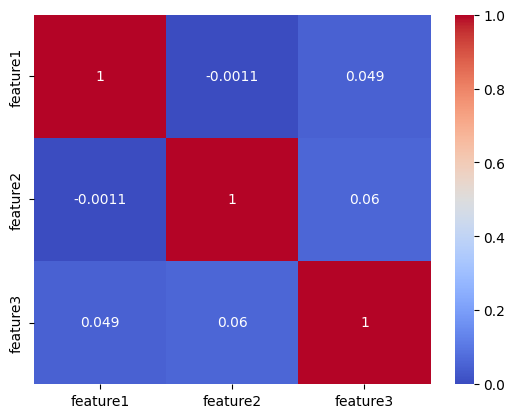

In [36]:
sns.heatmap(df.iloc[:,0:3].corr(), annot=True ,cmap='coolwarm')

# 3. Normal residual

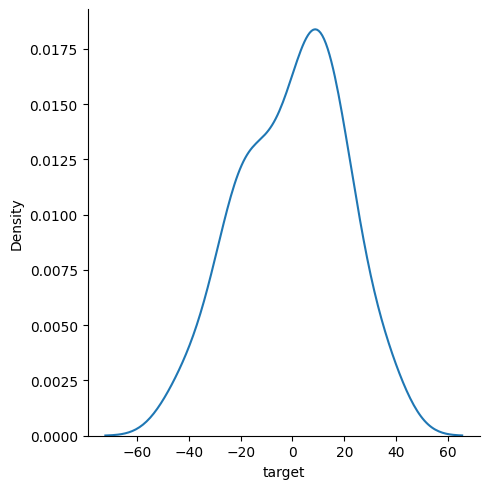

In [37]:
sns.displot(residuals, kind = 'kde')    

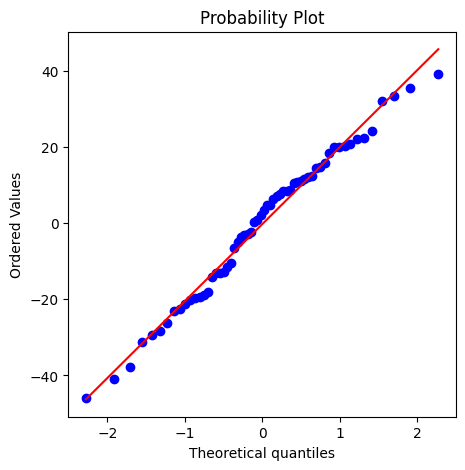

In [42]:
import scipy as sp

fig , ax = plt.subplots(figsize=(5,5))
sp.stats.probplot(residuals, dist='norm', plot=ax)
plt.show()


# 4. Homoscadasticity

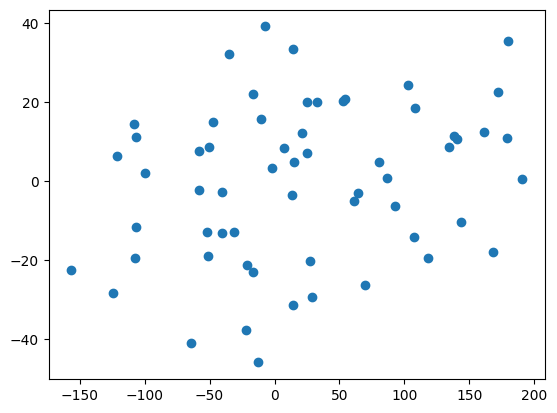

In [39]:
plt.scatter(y_pred, residuals)

# 5. Autocorrelation of Residuals

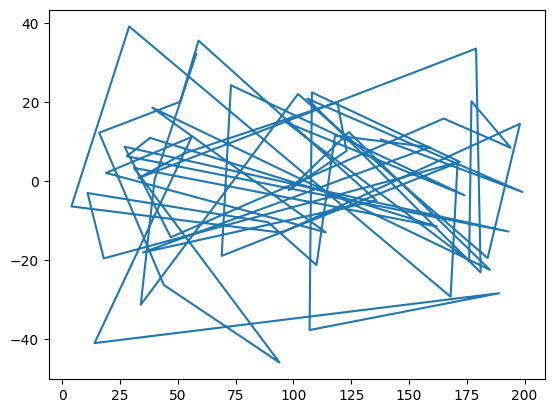

In [43]:
plt.plot(residuals)